# Biodiversity

***

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Cargar datos
species = pd.read_csv('species_info.csv')
obs = pd.read_csv('observations.csv')

In [3]:
# vista general
species.head()

,category,scientific_name,common_names,conservation_status
0,Mammal,Clethrionomys gapperi gapperi,Gapper's Red-Backed Vole,NaN
1,Mammal,Bos bison,"American Bison, Bison",NaN
2,Mammal,Bos taurus,"Aurochs, Aurochs, Domestic Cattle (Feral), Dom...",NaN
3,Mammal,Ovis aries,"Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)",NaN
4,Mammal,Cervus elaphus,Wapiti Or Elk,NaN


In [4]:
print('==== SPECIES INFO ====')
print('\nShape:', species.shape)
print('\nDtypes:', species.dtypes)
print('\nNulls:', species.isnull().sum())

==== SPECIES INFO ====

Shape: (5824, 4)

Dtypes: category               object
scientific_name        object
common_names           object
conservation_status    object
dtype: object

Nulls: category                  0
scientific_name           0
common_names              0
conservation_status    5633
dtype: int64


In [5]:
obs.head()

,scientific_name,park_name,observations
0,Vicia benghalensis,Great Smoky Mountains National Park,68
1,Neovison vison,Great Smoky Mountains National Park,77
2,Prunus subcordata,Yosemite National Park,138
3,Abutilon theophrasti,Bryce National Park,84
4,Githopsis specularioides,Great Smoky Mountains National Park,85


In [6]:
print('==== OBSERVATIONS ====')
print('\nShape:', obs.shape)
print('\nNulls:', obs.isnull().sum())

==== OBSERVATIONS ====

Shape: (23296, 3)

Nulls: scientific_name    0
park_name          0
observations       0
dtype: int64


__Duplicates__

Here we are searching for an entire row

In [7]:
print('\nDuplicate in spaces:', species.duplicated().sum())
print('\nDuplicate in obs:', obs.duplicated().sum())


Duplicate in spaces: 0

Duplicate in obs: 15


__Unique values in conservation_status__

In [8]:
print('\nConservation Status values:')
print(species.conservation_status.unique())


Conservation Status values:
[nan 'Species of Concern' 'Endangered' 'Threatened' 'In Recovery']


In [9]:
# Distribucion de conservation_status
print('\nCount of conservation_status:')
print(species.conservation_status.value_counts(dropna=False))


Count of conservation_status:
conservation_status
NaN                   5633
Species of Concern     161
Endangered              16
Threatened              10
In Recovery              4
Name: count, dtype: int64


## Cleaning the data

Filling the 'NaN' value with 'No Concern'

In [10]:
species.conservation_status = species.conservation_status.fillna('No Concern')
print(species.conservation_status.isnull().sum())
print(species.conservation_status.value_counts())

0
conservation_status
No Concern            5633
Species of Concern     161
Endangered              16
Threatened              10
In Recovery              4
Name: count, dtype: int64


__Duplicates in scientific_name__

Here we are searching duplicated in a subset value = scientific_name

In [11]:
print('\nDuplicated species:', species.scientific_name.duplicated().sum())
species = species.drop_duplicates(subset=['scientific_name'])
print('Shape after cleaning duplicated:', species.shape)


Duplicated species: 283
Shape after cleaning duplicated: (5541, 4)


_Distribution by category_

In [12]:
# Distribucion de especies por categoria
category_counts = species.category.value_counts().reset_index()
category_counts.columns = ['category', 'count']

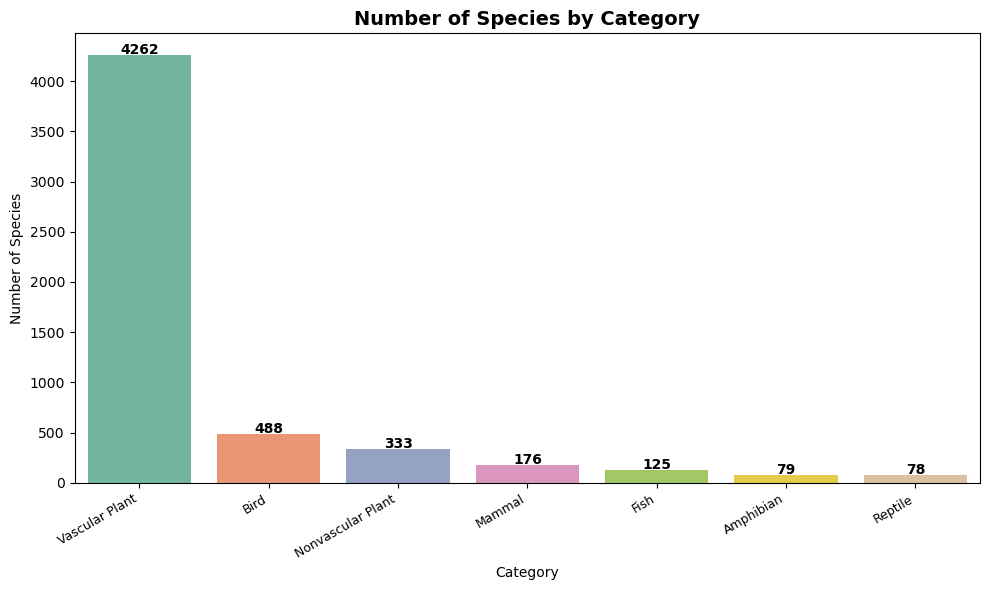

<Figure size 640x480 with 0 Axes>

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(data=category_counts, x='category', y='count',
            hue='category', palette='Set2', legend=False, ax=ax)

# Valores encima de cada barra
for i, row in category_counts.iterrows():
    ax.text(i, row['count'] + 10, str(row['count']),
            ha='center', fontsize=10, fontweight='bold')

ax.set_title("Number of Species by Category", fontsize=14, fontweight='bold')
ax.set_xlabel("Category")
ax.set_ylabel("Number of Species")
ax.set_xticks(range(len(category_counts)))
ax.set_xticklabels(category_counts['category'], rotation=30, ha='right', fontsize=9)

plt.tight_layout()
plt.show()
plt.clf()

__How the conservation status is distribuited?__

In [14]:
status_counts = species.conservation_status.value_counts().reset_index()
status_counts.columns = ['status', 'count']
status_counts

,status,count
0,No Concern,5363
1,Species of Concern,151
2,Endangered,15
3,Threatened,9
4,In Recovery,3


since 'No Concern' is the most part of the sample, we agregate a percentage column for better visualization 

In [15]:
status_counts['percentage'] = (status_counts['count'] / status_counts['count'].sum() * 100).round(2)

order = ['Endangered', 'Threatened', 'Species of Concern', 'In Recovery', 'No Concern']
order_risk = ['Endangered', 'Threatened', 'Species of Concern', 'In Recovery']

_Every state in percentage and only in danger state_

In [16]:
import matplotlib.gridspec as gridspec

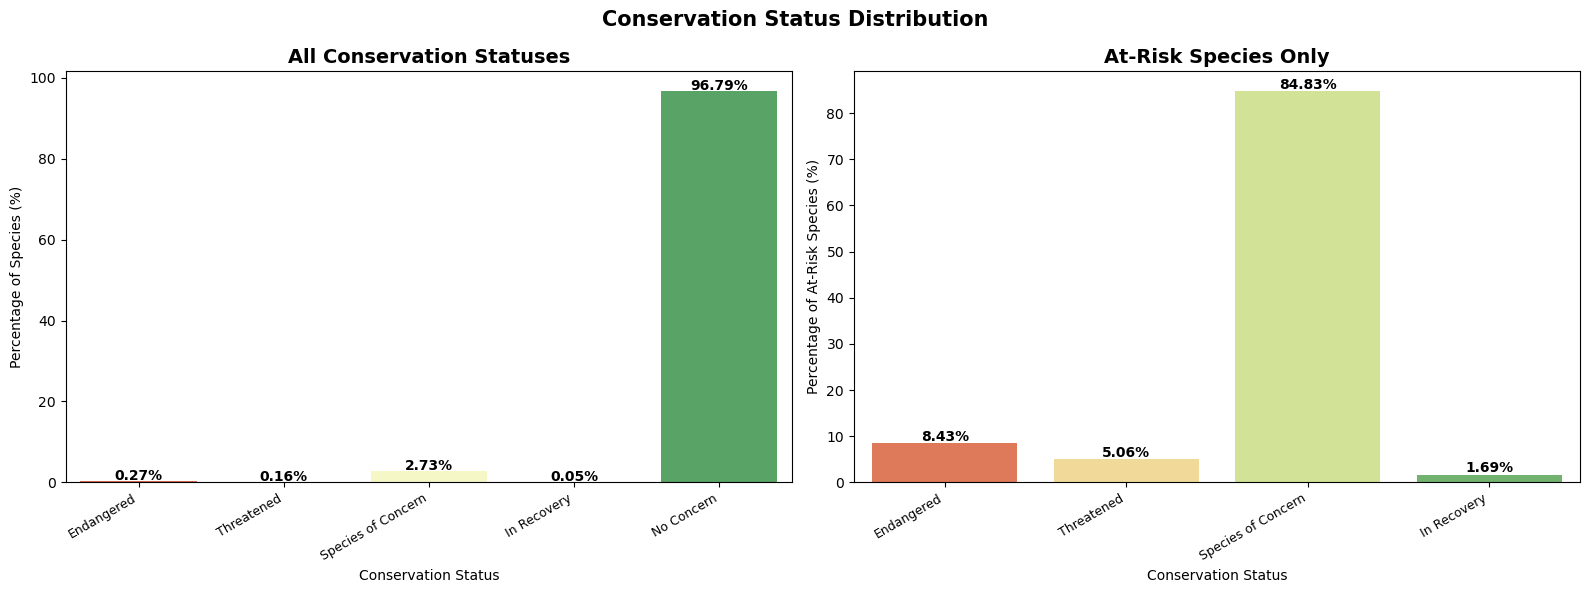

<Figure size 640x480 with 0 Axes>

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

status_ordered = status_counts.set_index('status').reindex(order).reset_index()

sns.barplot(data=status_ordered, x='status', y='percentage',
            hue='status', palette='RdYlGn', legend=False,
            order=order, ax=axes[0])

for i, row in status_ordered.iterrows():
    axes[0].text(i, row['percentage'] + 0.2, f"{row['percentage']}%",
                 ha='center', fontsize=10, fontweight='bold')

axes[0].set_title("All Conservation Statuses", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Conservation Status")
axes[0].set_ylabel("Percentage of Species (%)")
axes[0].set_xticks(range(len(order)))
axes[0].set_xticklabels(order, rotation=30, ha='right', fontsize=9)

at_risk = status_counts[status_counts['status'] != 'No Concern'].copy()
at_risk['percentage'] = (at_risk['count'] / at_risk['count'].sum() * 100).round(2)
at_risk_ordered = at_risk.set_index('status').reindex(order_risk).reset_index()

sns.barplot(data=at_risk_ordered, x='status', y='percentage',
            hue='status', palette='RdYlGn', legend=False,
            order=order_risk, ax=axes[1])

for i, row in at_risk_ordered.iterrows():
    axes[1].text(i, row['percentage'] + 0.5, f"{row['percentage']}%",
                 ha='center', fontsize=10, fontweight='bold')

axes[1].set_title("At-Risk Species Only", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Conservation Status")
axes[1].set_ylabel("Percentage of At-Risk Species (%)")
axes[1].set_xticks(range(len(order_risk)))
axes[1].set_xticklabels(order_risk, rotation=30, ha='right', fontsize=9)

plt.suptitle("Conservation Status Distribution", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
plt.clf()

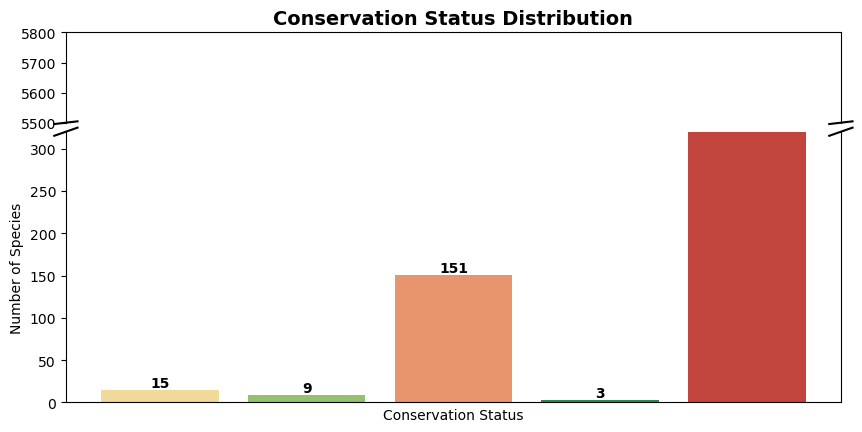

<Figure size 640x480 with 0 Axes>

In [26]:
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(10, 5),
                                      sharex=True,
                                      gridspec_kw={'height_ratios': [1, 3],
                                                   'hspace': 0.05})

order = ['Endangered', 'Threatened', 'Species of Concern', 'In Recovery', 'No Concern']
palette = ['#d73027', '#fc8d59', '#fee08b', '#91cf60', '#1a9850']

for ax in [ax_top, ax_bot]:
    sns.barplot(data=status_counts, x='status', y='count',
                hue='status', palette=palette, legend=False,
                order=order, ax=ax)

ax_top.set_ylim(5500, 5800)
ax_bot.set_ylim(0, 320)

status_ordered = status_counts.set_index('status').reindex(order).reset_index()
for i, row in status_ordered.iterrows():
    if row['count'] > 5500:
        ax_top.text(i, 5510, str(int(row['count'])),
                    ha='center', fontsize=10, fontweight='bold',
                    color='black', clip_on=True)  # <-- esto
    else:
        ax_bot.text(i, row['count'] + 3, str(int(row['count'])),
                    ha='center', fontsize=10, fontweight='bold',
                    clip_on=True)  # <-- y esto

ax_top.spines['bottom'].set_visible(False)
ax_bot.spines['top'].set_visible(False)
ax_top.tick_params(bottom=False)

d = 0.015
kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False)
ax_top.plot((-d, +d), (-d, +d), **kwargs)
ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)
kwargs.update(transform=ax_bot.transAxes)
ax_bot.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax_bot.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

ax_top.set_title("Conservation Status Distribution", fontsize=14, fontweight='bold')
ax_top.set_xlabel("")
ax_top.set_ylabel("")
ax_bot.set_xlabel("Conservation Status")
ax_bot.set_ylabel("Number of Species")
ax_bot.set_xticks(range(len(order)))
ax_bot.set_xticklabels(order, rotation=30, ha='right', fontsize=9)
ax_top.set_xticks([])

plt.subplots_adjust(hspace=0.05, top=0.92, bottom=0.18)
plt.show()
plt.clf()

__Which categories have most spices at risk?__

In [24]:
at_risk = species[species['conservation_status'] != 'No Concern']

category_status = at_risk.groupby(['category', 'conservation_status']).size().reset_index()
category_status.columns = ['category', 'conservation_status', 'count']
print(category_status)

             category conservation_status  count
0           Amphibian          Endangered      1
1           Amphibian  Species of Concern      4
2           Amphibian          Threatened      2
3                Bird          Endangered      4
4                Bird         In Recovery      3
5                Bird  Species of Concern     68
6                Fish          Endangered      3
7                Fish  Species of Concern      4
8                Fish          Threatened      3
9              Mammal          Endangered      6
10             Mammal  Species of Concern     22
11             Mammal          Threatened      2
12  Nonvascular Plant  Species of Concern      5
13            Reptile  Species of Concern      5
14     Vascular Plant          Endangered      1
15     Vascular Plant  Species of Concern     43
16     Vascular Plant          Threatened      2


In [25]:
status_order = ['Endangered', 'Threatened', 'Species of Concern', 'In Recovery']
palette = {'Endangered': '#d73027', 'Threatened': '#fc8d59', 
           'Species of Concern': '#fee08b', 'In Recovery': '#91cf60'}

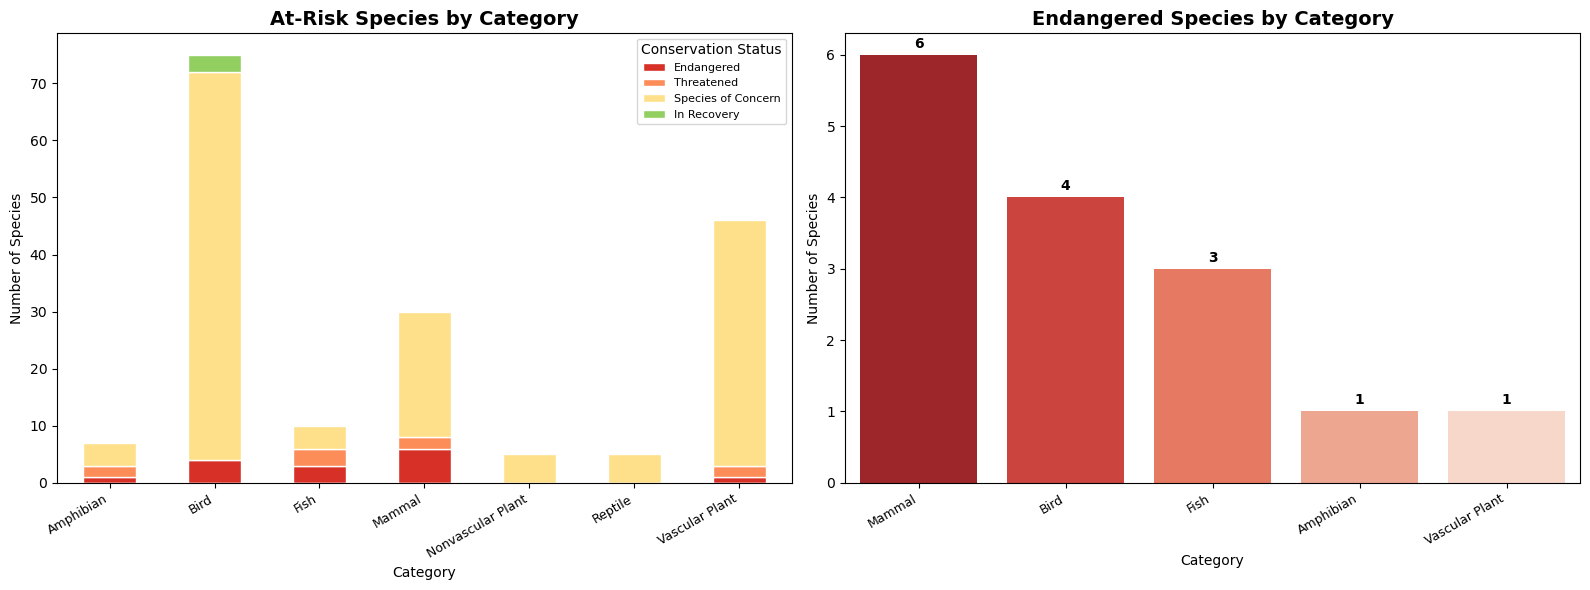

<Figure size 640x480 with 0 Axes>

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pivot = category_status.pivot_table(index='category', 
                                     columns='conservation_status', 
                                     values='count', 
                                     fill_value=0)
pivot = pivot.reindex(columns=status_order)
pivot.plot(kind='bar', stacked=True, 
           color=['#d73027', '#fc8d59', '#fee08b', '#91cf60'],
           ax=axes[0], edgecolor='white')

axes[0].set_title("At-Risk Species by Category", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Number of Species")
axes[0].legend(title="Conservation Status", fontsize=8, bbox_to_anchor=(1, 1))
axes[0].set_xticklabels(pivot.index, rotation=30, ha='right', fontsize=9)


endangered = at_risk[at_risk['conservation_status'] == 'Endangered']
endangered_counts = endangered.groupby('category').size().reset_index()
endangered_counts.columns = ['category', 'count']
endangered_counts = endangered_counts.sort_values('count', ascending=False)

sns.barplot(data=endangered_counts, x='category', y='count',
            hue='category', palette='Reds_r', legend=False, ax=axes[1])

for i, row in endangered_counts.reset_index().iterrows():
    axes[1].text(i, row['count'] + 0.1, str(int(row['count'])),
                 ha='center', fontsize=10, fontweight='bold')

axes[1].set_title("Endangered Species by Category", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Number of Species")
axes[1].set_xticks(range(len(endangered_counts)))
axes[1].set_xticklabels(endangered_counts['category'], rotation=30, ha='right', fontsize=9)

plt.tight_layout()
plt.show()
plt.clf()

__Observations by park__

In [33]:
park_obs = obs.groupby('park_name')['observations'].sum().reset_index()
park_obs.columns = ['park_name', 'total_observations']
park_obs = park_obs.sort_values('total_observations', ascending=False)
park_obs

,park_name,total_observations
2,Yellowstone National Park,1443562
3,Yosemite National Park,863332
0,Bryce National Park,576025
1,Great Smoky Mountains National Park,431820


In [34]:
obs_species = obs.merge(species[['scientific_name', 'category', 'conservation_status']], 
                         on='scientific_name', how='left')
print("\nNulos después del merge:", obs_species.isnull().sum())


Nulos después del merge: scientific_name        0
park_name              0
observations           0
category               0
conservation_status    0
dtype: int64


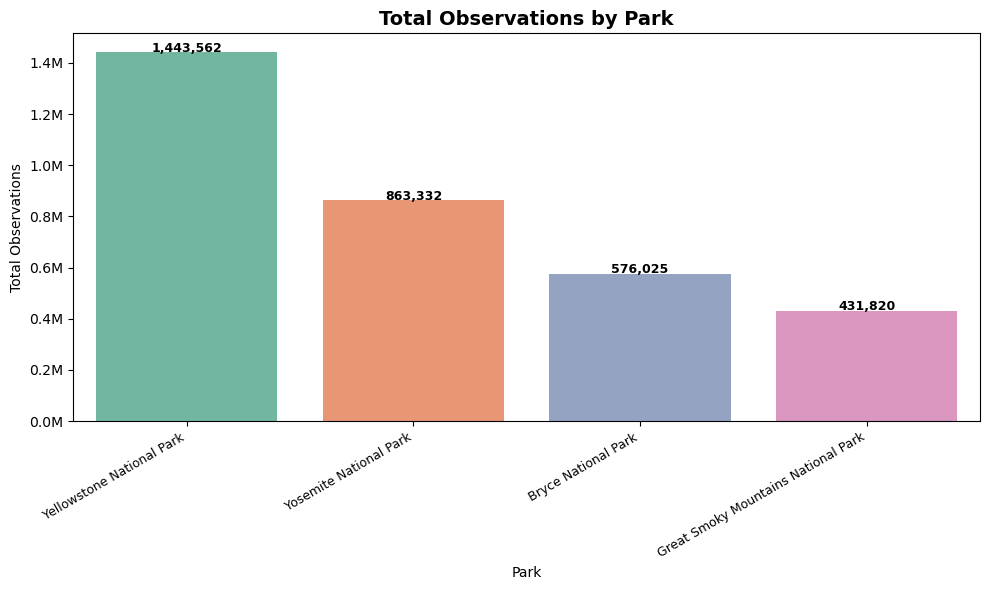

<Figure size 640x480 with 0 Axes>

In [39]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(data=park_obs, x='park_name', y='total_observations',
            hue='park_name', palette='Set2', legend=False, ax=ax)

for i, row in park_obs.reset_index().iterrows():
    ax.text(i, row['total_observations'] + 1000,
            f"{int(row['total_observations']):,}",
            ha='center', fontsize=9, fontweight='bold')

ax.set_title("Total Observations by Park", fontsize=14, fontweight='bold')
ax.set_xlabel("Park")
ax.set_ylabel("Total Observations")
ax.set_xticks(range(len(park_obs)))
ax.set_xticklabels(park_obs['park_name'], rotation=30, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.show()
plt.clf()

_Observations by park and category_

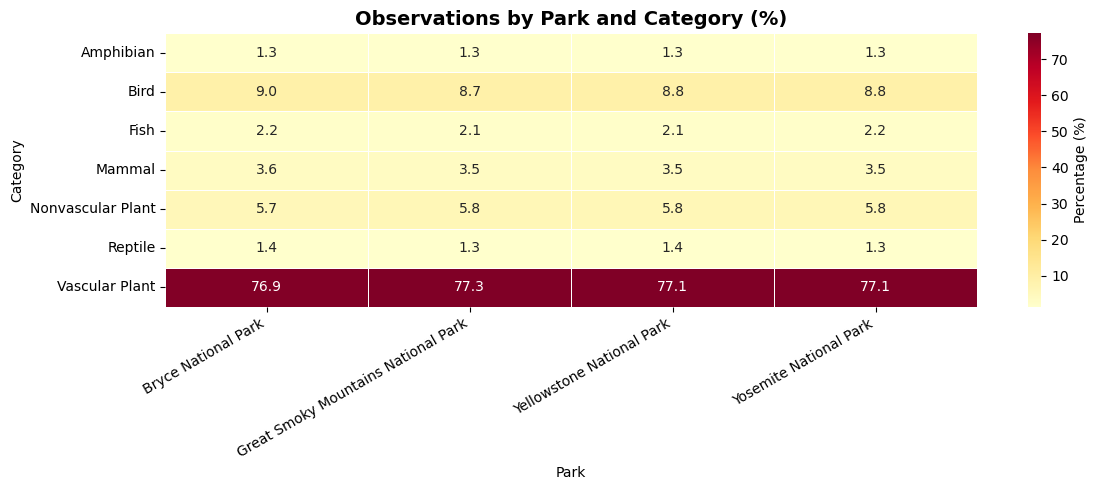

In [41]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.heatmap(pivot_park_pct.T, annot=True, fmt='.1f',
            cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Percentage (%)'}, ax=ax)

ax.set_title("Observations by Park and Category (%)", fontsize=14, fontweight='bold')
ax.set_xlabel("Park")
ax.set_ylabel("Category")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

__Species at risk by park__

In [43]:
at_risk_species = species[species['conservation_status'] != 'No Concern']

at_risk_obs = obs.merge(at_risk_species[['scientific_name', 'category', 'conservation_status']], 
                         on='scientific_name', how='inner')


print("Shape:", at_risk_obs.shape)
print("\nPrimeras filas:")
at_risk_obs.head()

Shape: (760, 5)

Primeras filas:


,scientific_name,park_name,observations,category,conservation_status
0,Zizia trifoliata,Yosemite National Park,135,Vascular Plant,Species of Concern
1,Camissonia sierrae ssp. alticola,Bryce National Park,84,Vascular Plant,Species of Concern
2,Tofieldia glabra,Great Smoky Mountains National Park,75,Vascular Plant,Species of Concern
3,Accipiter cooperii,Bryce National Park,95,Bird,Species of Concern
4,Dichanthelium acuminatum var. acuminatum,Yosemite National Park,123,Vascular Plant,Species of Concern


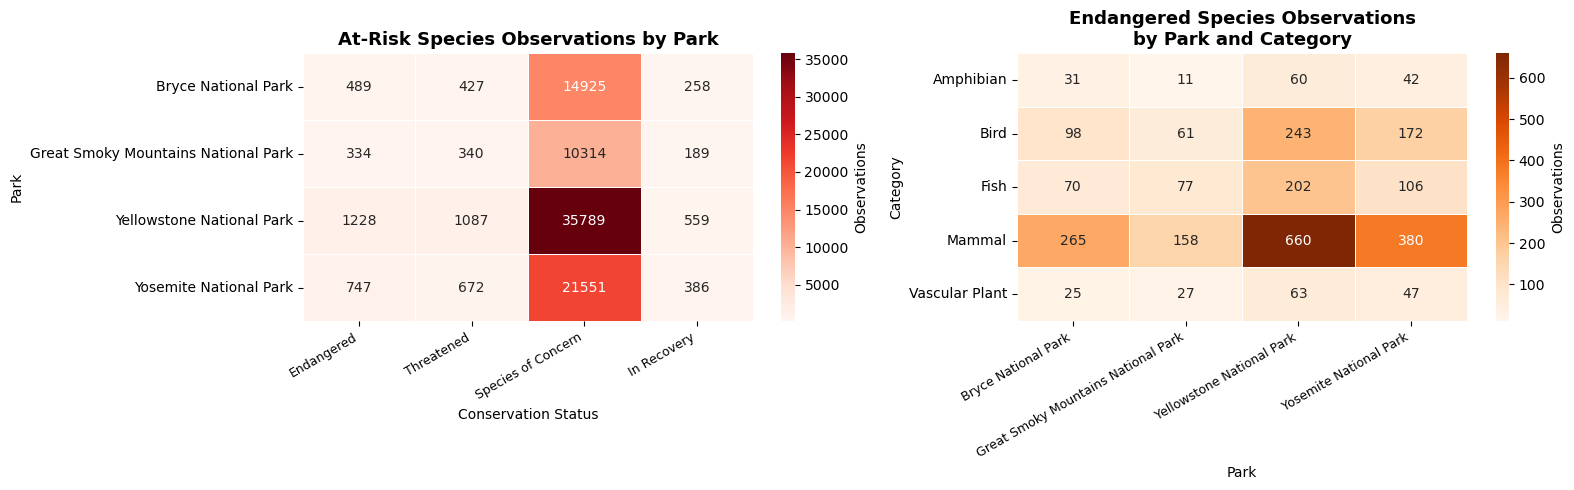

<Figure size 640x480 with 0 Axes>

In [44]:
park_risk = at_risk_obs.groupby(['park_name', 'conservation_status'])['observations'].sum().reset_index()

pivot_risk = park_risk.pivot_table(index='park_name', 
                                    columns='conservation_status', 
                                    values='observations', 
                                    fill_value=0)

status_order = ['Endangered', 'Threatened', 'Species of Concern', 'In Recovery']
pivot_risk = pivot_risk.reindex(columns=status_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# heatmap obs risk by park
sns.heatmap(pivot_risk, annot=True, fmt='.0f',
            cmap='Reds', linewidths=0.5,
            cbar_kws={'label': 'Observations'}, ax=axes[0])

axes[0].set_title("At-Risk Species Observations by Park", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Conservation Status")
axes[0].set_ylabel("Park")
axes[0].set_xticklabels(status_order, rotation=30, ha='right', fontsize=9)


# endangered by park and category
endangered_obs = at_risk_obs[at_risk_obs['conservation_status'] == 'Endangered']
endangered_park = endangered_obs.groupby(['park_name', 'category'])['observations'].sum().reset_index()

pivot_endangered = endangered_park.pivot_table(index='category',
                                                columns='park_name',
                                                values='observations',
                                                fill_value=0)

sns.heatmap(pivot_endangered, annot=True, fmt='.0f',
            cmap='Oranges', linewidths=0.5,
            cbar_kws={'label': 'Observations'}, ax=axes[1])

axes[1].set_title("Endangered Species Observations\nby Park and Category", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Park")
axes[1].set_ylabel("Category")
axes[1].set_xticklabels(pivot_endangered.columns, rotation=30, ha='right', fontsize=9)

plt.tight_layout()
plt.show()
plt.clf()

## Protecting What We Have: A look at Endangered Species in America's National Parks

America's national parks are home to thousands of species — from towering trees to elusive mammals. But how many of these species are truly at risk? Using data from the National Park Service, we analyzed the conservation status of over 5,800 species across four parks: Yellowstone, Yosemite, Great Smoky Mountains, and Bryce Canyon.

***

__Most Species Are Safe-But Not All__

The good news first: the vast majority of species in our dataset show no conservation concern. However, when we zoom in on the species that do need attention, the numbers tell an important story.


Of all at-risk species, Species of Concern is the most common status, followed by Threatened and Endangered. A small but meaningful group has already started recovering — classified as In Recovery — which shows that conservation efforts can and do work.


***

__Birds and Mammals Face the Greatest Threat__

Not all species face the same level of risk. Birds have the highest number of at-risk species across all categories, followed by Vascular Plants and Mammals. While plants dominate the total number of observations in every park, they represent a smaller proportion of truly endangered species compared to birds and fish.


***

__The Parks Are Not Equal__

When we look at where endangered species are being observed, clear differences emerge between parks. Some parks record significantly more sightings of at-risk species than others, which may reflect both the diversity of their ecosystems and the intensity of monitoring efforts.


***

## What This Means

The data makes one thing clear: while most species in our national parks are stable, a vulnerable minority needs our active protection. Birds, fish, and certain mammals are the groups most in need of intervention.

Conservation works — the In Recovery category proves it. The challenge now is making sure we extend those efforts to every species that needs them, in every park that holds them.